In [ ]:
# Imports and Setup
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pretty_midi

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.config import PROCESSED_DIR, CHECKPOINTS_DIR, GENERATED_MIDIS_DIR, PLOTS_DIR, START_PITCH, FS, BATCH_SIZE, EPOCHS_AUTOENCODER, LEARNING_RATE
from src.models.autoencoder import LSTMAutoencoder
from src.utils.losses import BinaryFocalLoss

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

mkdir -p failed for path C:\Users\User\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\User\\.matplotlib'
Matplotlib created a temporary cache directory at C:\Users\User\AppData\Local\Temp\matplotlib-tm6svu6a because there was an issue with the default path (C:\Users\User\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Training on device: cuda


In [ ]:
# DataLoader Setup
class PianoRollDataset(Dataset):
    def __init__(self, npy_path):
        self.data = np.load(npy_path)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        # Convert to float32 tensor
        return torch.tensor(self.data[idx], dtype=torch.float32)

print("Loading datasets...")
train_dataset = PianoRollDataset(PROCESSED_DIR / "maestro_train_windows.npy")
val_dataset = PianoRollDataset(PROCESSED_DIR / "maestro_validation_windows.npy")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Loading datasets...
Train batches: 897 | Val batches: 111


In [3]:
# Training Loop
model = LSTMAutoencoder().to(device)
criterion = BinaryFocalLoss(alpha=0.8, gamma=2.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
epochs = EPOCHS_AUTOENCODER  # from config.py (default 50)

print("Starting training...")
for epoch in range(epochs):
    model.train()
    batch_losses = []
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass (returns raw logits)
        reconstructed_logits = model(batch)
        
        # Calculate loss
        loss = criterion(reconstructed_logits, batch)
        
        # Backward pass
        loss.backward()
        
        # Add gradient clipping to prevent exploding gradients (as per supplementary guide)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        batch_losses.append(loss.item())
        
    train_losses.append(np.mean(batch_losses))
    
    # Validation step
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits = model(batch)
            loss = criterion(logits, batch)
            val_batch_losses.append(loss.item())
            
    val_losses.append(np.mean(val_batch_losses))
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

# Save the checkpoint
torch.save(model.state_dict(), CHECKPOINTS_DIR / "task1_lstm_ae.pth")
print("Training complete and model saved.")

Starting training...
Epoch [1/50] | Train Loss: 0.0441 | Val Loss: 0.0427
Epoch [5/50] | Train Loss: 0.0435 | Val Loss: 0.0426
Epoch [10/50] | Train Loss: 0.0435 | Val Loss: 0.0425
Epoch [15/50] | Train Loss: 0.0435 | Val Loss: 0.0425
Epoch [20/50] | Train Loss: 0.0435 | Val Loss: 0.0426
Epoch [25/50] | Train Loss: 0.0435 | Val Loss: 0.0426
Epoch [30/50] | Train Loss: 0.0435 | Val Loss: 0.0425
Epoch [35/50] | Train Loss: 0.0435 | Val Loss: 0.0426
Epoch [40/50] | Train Loss: 0.0435 | Val Loss: 0.0425
Epoch [45/50] | Train Loss: 0.0435 | Val Loss: 0.0425
Epoch [50/50] | Train Loss: 0.0435 | Val Loss: 0.0426
Training complete and model saved.


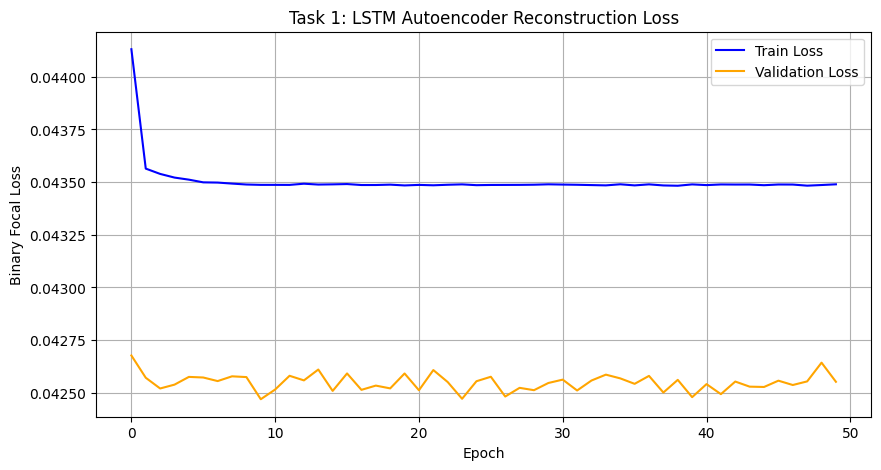

Saved loss curve to Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\plots\task1_loss_curve.png


In [4]:
# Plot Reconstruction Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Task 1: LSTM Autoencoder Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Focal Loss')
plt.legend()
plt.grid(True)

plot_path = PLOTS_DIR / "task1_loss_curve.png"
plt.savefig(plot_path)
plt.show()
print(f"Saved loss curve to {plot_path}")

In [5]:
# Generate 5 MIDI Samples
def matrix_to_midi(matrix, output_path, threshold=0.4):
    """Converts a probability matrix back to a MIDI file."""
    # Apply threshold below 0.5 to recover suppressed activations
    binary_matrix = (matrix > threshold).astype(int)
    
    midi = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    
    frame_duration = 1.0 / FS
    
    for pitch_idx in range(binary_matrix.shape[1]):
        pitch = pitch_idx + START_PITCH
        # Find continuous segments of 1s
        active_frames = np.where(binary_matrix[:, pitch_idx] == 1)[0]
        
        if len(active_frames) == 0:
            continue
            
        # Group consecutive frames into single long notes
        consecutive_groups = np.split(active_frames, np.where(np.diff(active_frames) != 1)[0] + 1)
        
        for group in consecutive_groups:
            start_time = group[0] * frame_duration
            end_time = (group[-1] + 1) * frame_duration
            note = pretty_midi.Note(velocity=80, pitch=pitch, start=start_time, end=end_time)
            piano.notes.append(note)
            
    midi.instruments.append(piano)
    midi.write(str(output_path))
    
model.eval()
num_samples = 5
print(f"Generating {num_samples} MIDI samples...")

with torch.no_grad():
    # Sample from standard normal distribution
    latent_samples = torch.randn(num_samples, model.latent_dim).to(device)
    
    # Decode sequence length of 128
    generated_logits = model.decode(latent_samples, seq_len=128)
    
    # Convert logits to probabilities
    generated_probs = torch.sigmoid(generated_logits).cpu().numpy()

for i in range(num_samples):
    out_path = GENERATED_MIDIS_DIR / f"task1_sample_{i+1}.mid"
    matrix_to_midi(generated_probs[i], out_path, threshold=0.4)
    print(f"Saved {out_path}")

Generating 5 MIDI samples...
Saved Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task1_sample_1.mid
Saved Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task1_sample_2.mid
Saved Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task1_sample_3.mid
Saved Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task1_sample_4.mid
Saved Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task1_sample_5.mid
